<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
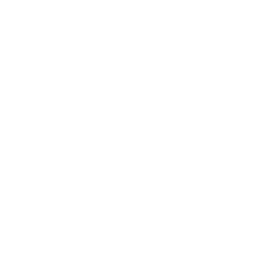
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ressourceudnyttelse på hospitalsafdelinger — vandret søjlediagram</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Sundhedsvæsen / Hospitalsdrift &nbsp;|&nbsp; marts 2026</p>
</div>
</div>
</div>

## Resumé

Dette eksempel bruger **PROC GCHART**s vandrette søjlediagrammer (HBAR) til at profilere personaletimer på tværs af seks kliniske afdelinger for 1. kvartal 2026. En syntetisk arbejdsstyrkelog med **90 vagtregistreringer** (15 pr. afdeling) driver tre visninger: et rangeret søjlediagram over samlede timer, gennemsnitlig vagtlængde pr. afdeling og grupperede HBAR'er, der opdeler hver afdeling efter ressourcekategori og efter vagt. `SUMVAR=` akkumulerer faktiske arbejdstimer i stedet for at tælle registreringer, `TYPE=SUM`/`TYPE=MEAN` skifter responsstatistikken, `DESCENDING` rangerer afdelingerne, og `GROUP=` tegner tilstødende klyngede søjler for en anden dimension.

Output understøtter den kvartalsvise driftseffektivitetsgennemgang: den viser, hvilke afdelinger der bruger flest arbejdstimer, hvilke der kører de længste vagter, og hvordan dag-/aften-/nat-bemandingsmønstret adskiller sig mellem afdelinger med kontinuerlig akut behandling og dagorienterede services.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Individuelle vagtregistreringer med arbejdstimer | 90 |
| WORK.DEPT_SUMMARY | Afdelingstotaler og gennemsnitlig vagtlængde | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generer en syntetisk arbejdsstyrkelog for hospitalspersonale.
   1. kvartal 2026: 6 kliniske afdelinger, 4 ressourcekategorier,
   3 vagter. Dimensioneret til 15 vagtregistreringer pr. afdeling
   (90 i alt), så hele afdelingslisten forbliver synlig.
   -------------------------------------------------------- */
data work.staffing_log;
    CALL streaminit(20260601);
    LÆNGDE department $20 resource_type $20 shift $6;

    /* ressourcekategori-fordeling (sygeplejetung klinisk bemanding) */
    TABEL resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* grundlæggende vagtfordeling, vægtet mod nat for døgnåbne enheder */
    TABEL shfw[3] _temporary_ (0.45 0.30 0.25);
    TABEL nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    GØR di = 1 TIL 6;
        /* Afdelingsnavn: direkte if/else-kæde (ikke et _temporary_
           array) fordi de danske navne indeholder diakritiske tegn
           (fx "Pædiatri") -- se motoradvarslen om _temporary_-array-
           opslag med ikke-ASCII strengliteraler. */
        HVIS      di = 1 SÅ department = "Skadestue";
        ELLERS HVIS di = 2 SÅ department = "Kirurgi";
        ELLERS HVIS di = 3 SÅ department = "Intensiv";
        ELLERS HVIS di = 4 SÅ department = "Pædiatri";
        ELLERS HVIS di = 5 SÅ department = "Onkologi";
        ELLERS                 department = "Barsel";

        GØR rec = 1 TIL 15;

            /* ressourcetype via vægtet udtræk */
            u = rand('uniform'); cum = 0;
            GØR r = 1 TIL 4;
                cum + resw[r];
                HVIS u <= cum SÅ GØR;
                    HVIS      r = 1 SÅ resource_type = "Sygepleje";
                    ELLERS HVIS r = 2 SÅ resource_type = "Læge";
                    ELLERS HVIS r = 3 SÅ resource_type = "Sundhedsfaglige";
                    ELLERS               resource_type = "Support";
                    FORLAD;
                SLUT;
            SLUT;

            /* vagt via afdelingsspecifik nat-vægtning */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            HVIS u <= w1 SÅ shift = 'Dag';
            ELLERS HVIS u <= w1 + w2 SÅ shift = 'Aften';
            ELLERS shift = 'Nat';

            /* timer: læger og kirurgi kører længere vagter */
            BASE = 8;
            HVIS resource_type = 'Læge' SÅ BASE = BASE + 1.5;
            HVIS department = 'Kirurgi'  SÅ BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            HVIS hours_worked < 4 SÅ hours_worked = 4;

            UDDATA;
        SLUT;
    SLUT;
    BEHOLD department resource_type shift hours_worked;
KØR;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Afdelingstotaler og gennemsnitlig vagtlængde,
   rangeret efter samlede arbejdstimer.
   -------------------------------------------------------- */
PROCEDURE SQL;
    CREATE TABLE work.dept_summary AS
    VÆLG department,
           sum(hours_worked)  AS total_hours   format=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  format=6.2
    FROM work.staffing_log
    GROUP EFTER department
    ORDER EFTER total_hours DESC;
QUIT;

PROCEDURE UDSKRIV data=work.dept_summary noobs MÆRKAT;
    MÆRKAT total_hours   = 'Timer i alt'
          shift_count   = 'Antal vagter'
          avg_shift_hrs = 'Gnsn. vagt (timer)';
    TITEL 'Afdelingsopgørelse over arbejdstimer - 1. kvartal 2026';
KØR;
TITEL;

                                 Afdelingsopgørelse over arbejdstimer - 1. kvartal 2026                                 

department  Timer i alt  Antal vagter  Gnsn. vagt (timer)
Kirurgi          136.25            15                9.08
Intensiv         128.50            15                8.57
Barsel           127.75            15                8.52
Pædiatri         124.75            15                8.32
Onkologi         123.75            15                8.25
Skadestue        119.25            15                7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                              Arbejdstimer efter afdeling                                               

                                                  The MEANS Procedure

                                     Analysis Variable : hours_worked Arbejdstimer

        Afdeling             Sum           Mean          N Obs
        ------------------------------------------------------
        Barsel            127.75           8.52             15
        Intensiv          128.50           8.57             15
        Kirurgi           136.25           9.08             15
        Onkologi          123.75           8.25             15
        Pædiatri          124.75           8.32             15
        Skadestue         119.25           7.95             15
        ------------------------------------------------------

                                              Vagtfordeling efter afdeling                                              

                                 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


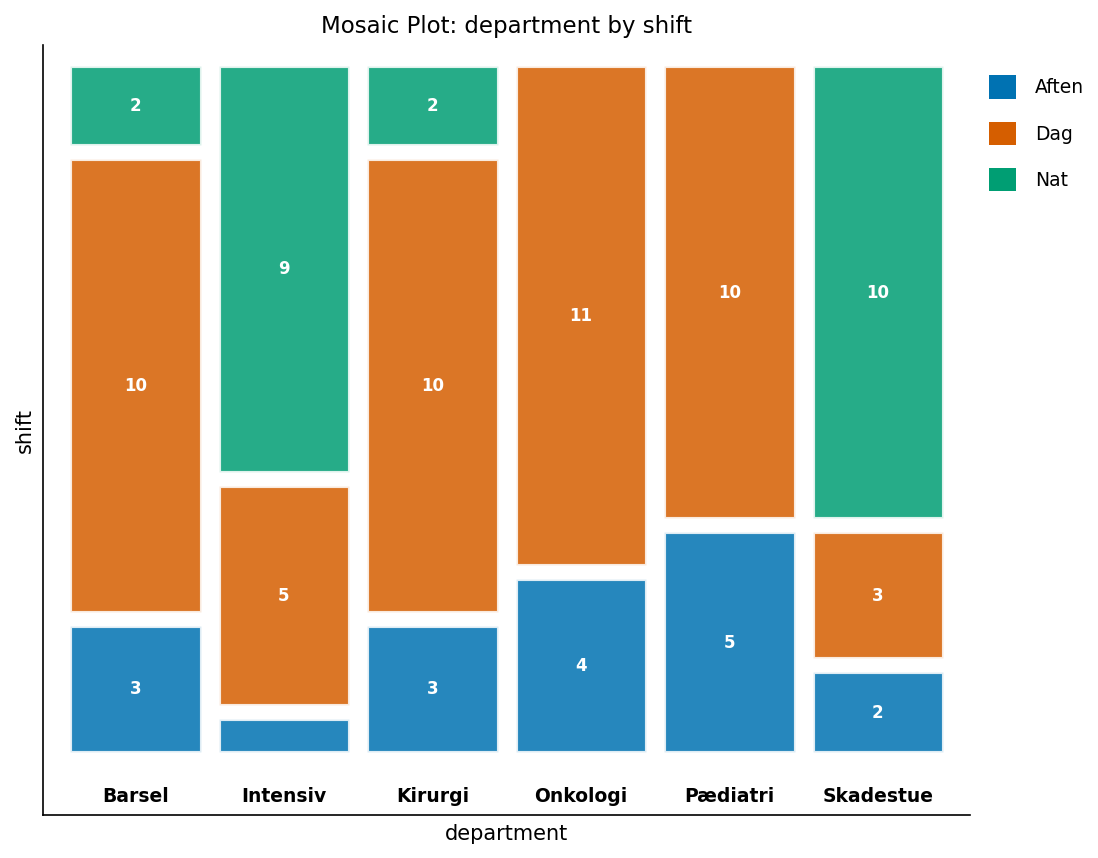

In [3]:
/* --------------------------------------------------------
   Baseline-tabeller: arbejdstimer efter afdeling, og
   fordelingen af dag-/aften-/nat-vagter pr. afdeling.
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.staffing_log sum mean n maxdec=2;
    KLASSE department;
    VARIABEL hours_worked;
    MÆRKAT department="Afdeling" hours_worked="Arbejdstimer";
    TITEL 'Arbejdstimer efter afdeling';
KØR;

PROCEDURE FREKVENSER data=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    MÆRKAT department="Afdeling" shift="Vagt";
    TITEL 'Vagtfordeling efter afdeling';
KØR;
TITEL;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


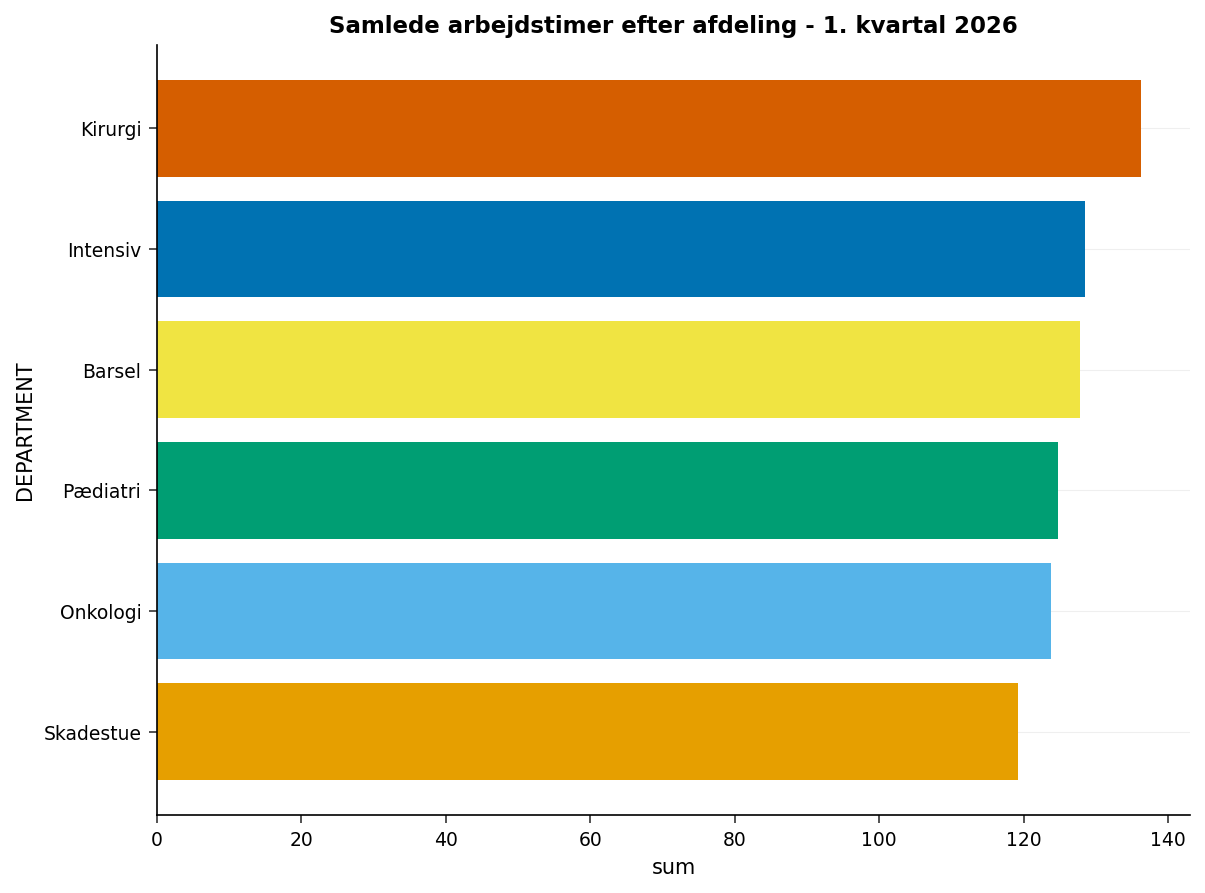

In [4]:
/* --------------------------------------------------------
   Oversigts-HBAR: samlede arbejdstimer efter afdeling.
   SUMVAR= akkumulerer timer; DESCENDING rangerer søjlerne.
   -------------------------------------------------------- */
PROCEDURE GCHART data=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      FALDENDE;
    MÆRKAT department="Afdeling" hours_worked="Arbejdstimer";
    TITEL 'Samlede arbejdstimer efter afdeling - 1. kvartal 2026';
KØR;
QUIT;
TITEL;

### Opdeling af hver afdeling efter ressourcekategori

`GROUP=` tegner en klynge af tilstødende vandrette søjler for hver afdeling, én søjle pr. ressourcekategori. Fordi `SUMVAR=hours_worked` er i kraft, måler hver søjle akkumulerede arbejdstimer i stedet for et antal registreringer, så diagrammet viser, hvordan sygepleje-, læge-, sundhedsfaglig- og supporttimer sammenlignes *inden for* hver afdeling.

In [5]:
/* --------------------------------------------------------
   PATTERN-sætninger: koordineret 4-farvet palet
   ét mønster pr. ressourcetype-undergruppe
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Sygepleje — mørkeblå   */
pattern2 VALUE=solid color=cx28A745;   /* Læge — grøn            */
pattern3 VALUE=solid color=cxE8650A;   /* Sundhedsfaglige — rav  */
pattern4 VALUE=solid color=cx6C757D;   /* Support — grå          */

                                    Afdelingens arbejdstimer efter ressourcekategori                                    


Kilde: Arbejdsstyrke-styringssystem | Rapporteringsperiode: jan-mar 2026



NOTE: Option TITLE changed to Afdelingens arbejdstimer efter ressourcekategori.
NOTE: Option FOOTNOTE changed to Kilde: Arbejdsstyrke-styringssystem | Rapporteringsperiode: jan-mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


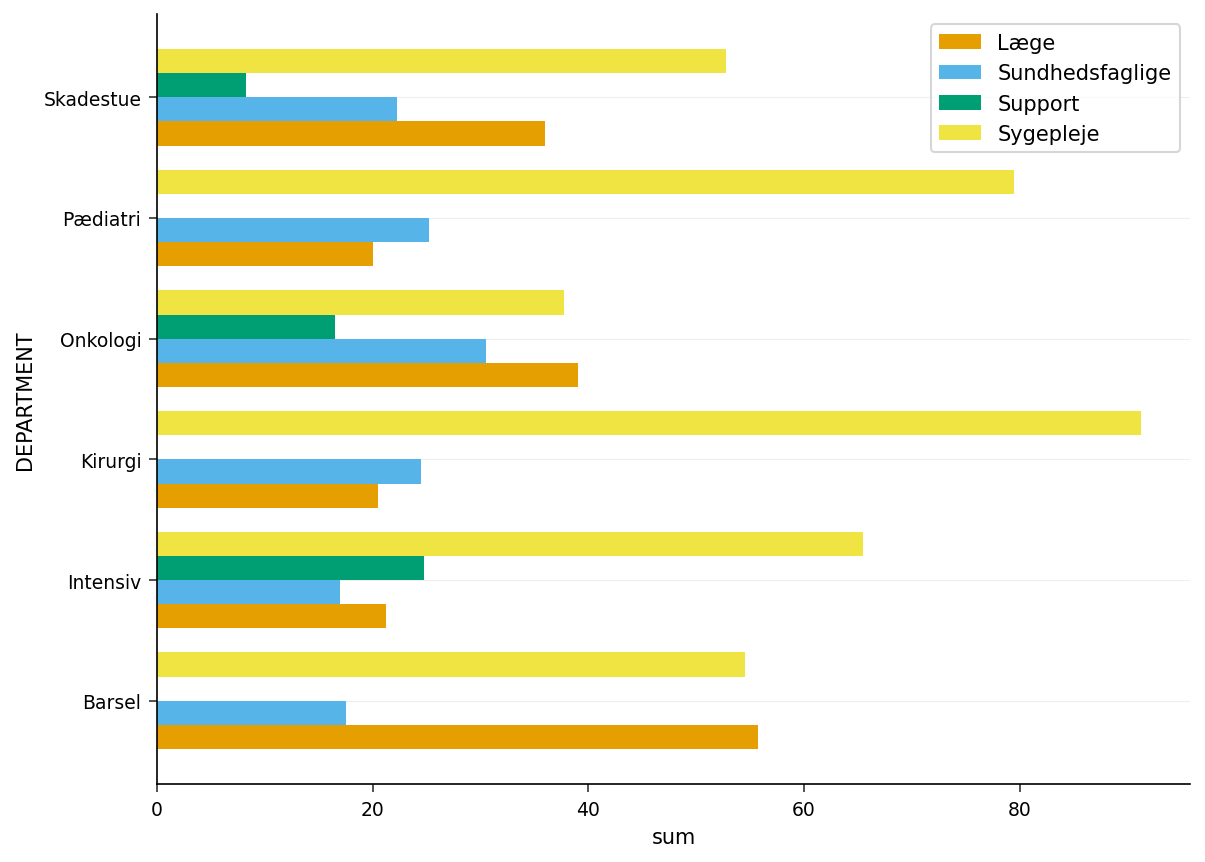

In [6]:
/* --------------------------------------------------------
   HBAR grupperet efter ressourcekategori (GROUP=).
   Hver afdeling bliver til en klynge af søjler -- én pr.
   ressourcetype -- målt i akkumulerede arbejdstimer.
   -------------------------------------------------------- */
TITEL 'Afdelingens arbejdstimer efter ressourcekategori';
footnote JUSTIFY=LEFT
    'Kilde: Arbejdsstyrke-styringssystem | Rapporteringsperiode: jan-mar 2026';

PROCEDURE GCHART data=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    MÆRKAT department="Afdeling" resource_type="Ressourcekategori" hours_worked="Arbejdstimer";
KØR;
QUIT;

TITEL; footnote;

                                          Afdelingens arbejdstimer efter vagt                                           


Grupperede søjler adskiller dag-/aften-/nat-bidrag pr. afdeling



NOTE: Option TITLE changed to Afdelingens arbejdstimer efter vagt.
NOTE: Option FOOTNOTE changed to Grupperede søjler adskiller dag-/aften-/nat-bidrag pr. afdeling.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


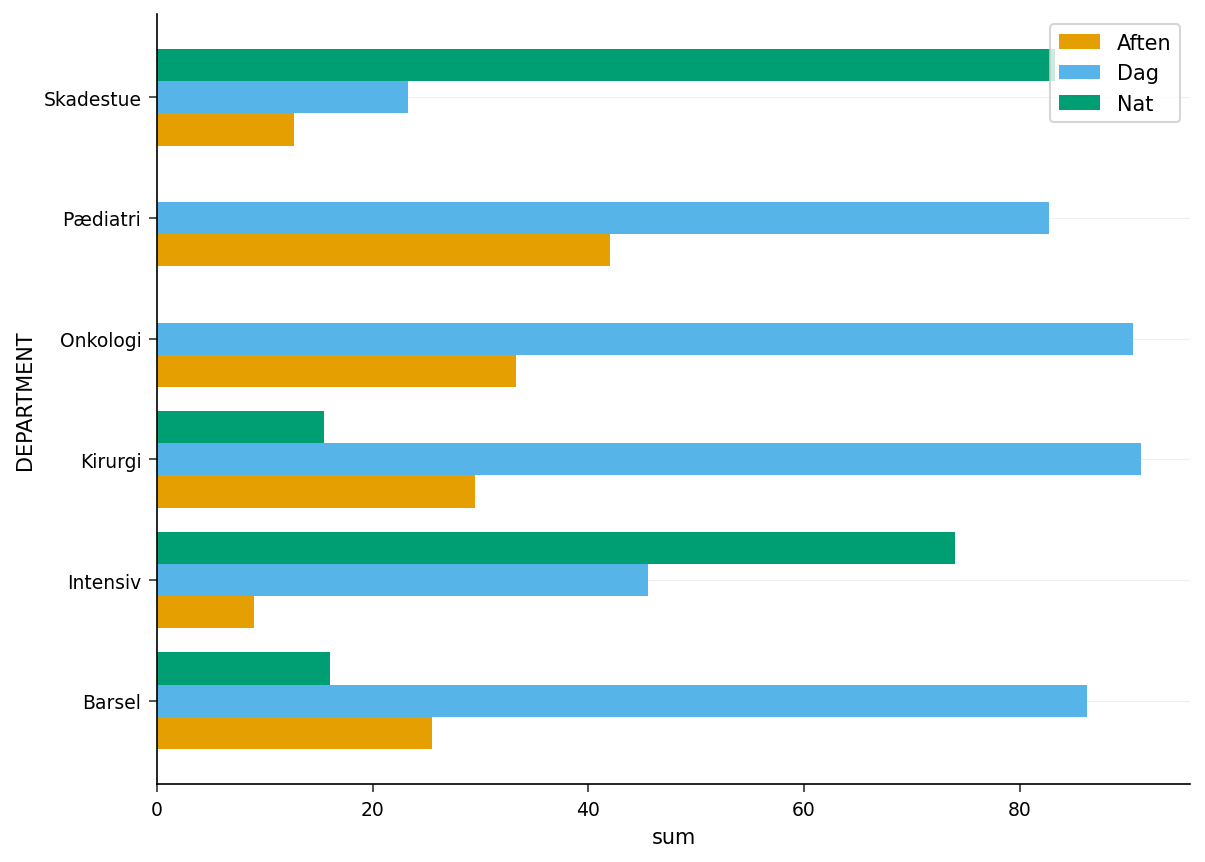

In [7]:
/* --------------------------------------------------------
   HBAR grupperet efter vagt (GROUP=).
   Adskiller dag-/aften-/nat-arbejdstimer inden for hver
   afdeling -- og fremhæver enhederne med døgnåben akutbehandling.
   -------------------------------------------------------- */
TITEL 'Afdelingens arbejdstimer efter vagt';
footnote JUSTIFY=LEFT
    'Grupperede søjler adskiller dag-/aften-/nat-bidrag pr. afdeling';

PROCEDURE GCHART data=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    MÆRKAT department="Afdeling" shift="Vagt" hours_worked="Arbejdstimer";
KØR;
QUIT;

TITEL; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


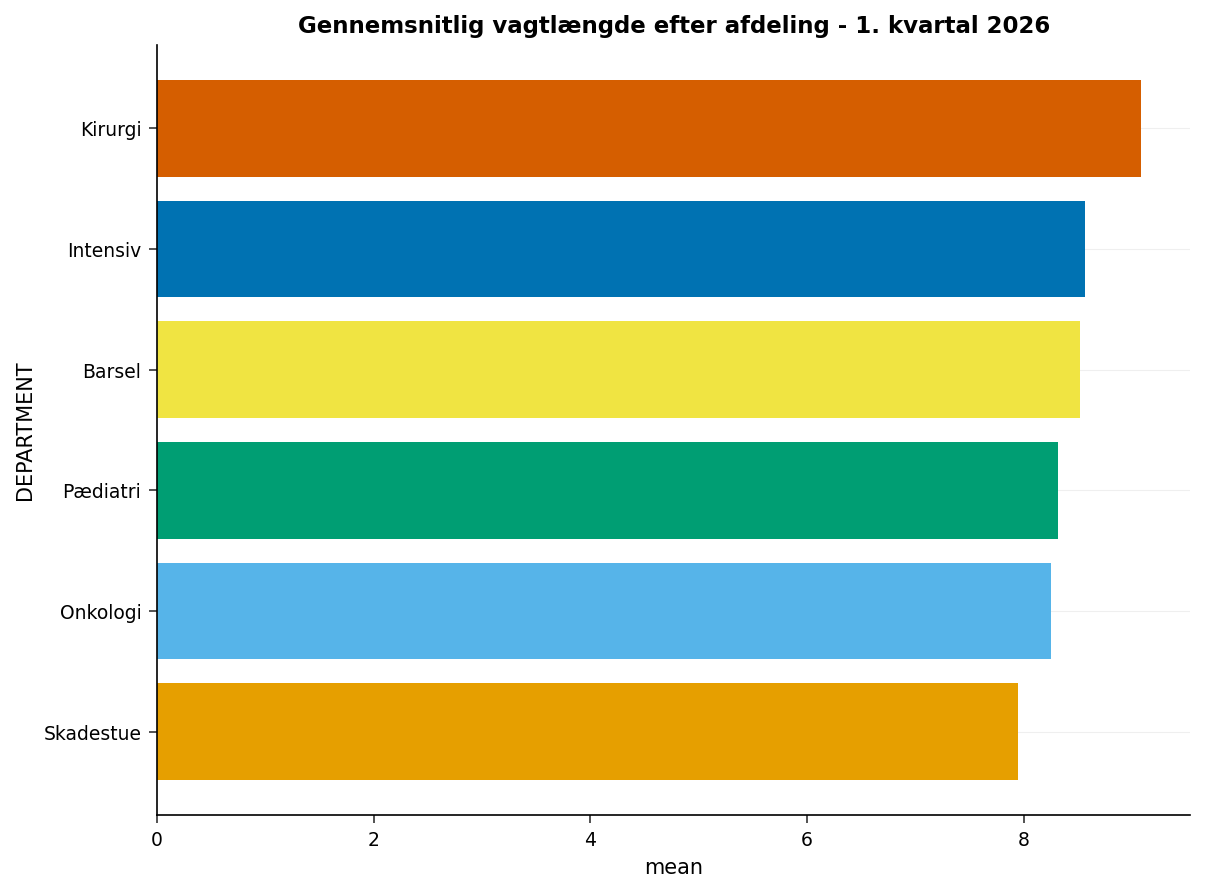

In [8]:
/* --------------------------------------------------------
   Gennemsnitlig vagtlængde pr. afdeling (TYPE=MEAN).
   Afslører, om en afdeling kører lange vagter eller mange
   kortere, uafhængigt af den samlede volumen.
   -------------------------------------------------------- */
PROCEDURE GCHART data=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      FALDENDE;
    MÆRKAT department="Afdeling" hours_worked="Arbejdstimer";
    TITEL 'Gennemsnitlig vagtlængde efter afdeling - 1. kvartal 2026';
KØR;
QUIT;
TITEL;

---

### Fortolkning

På tværs af de 90 vagtregistreringer ligger de samlede arbejdstimer i et snævert bånd fra **119.25** (Skadestue) til **136.25** (Kirurgi), fordi hver afdeling har de samme 15 vagter i denne periode — så rangeringen afspejler **vagtlængden**, ikke antallet af vagter. Kirurgi topper både diagrammet over samlede timer og diagrammet over gennemsnitlig vagtlængde med **9.08 timer** pr. vagt, hvilket stemmer overens med længere operative forløb og det lægetunge personalebehov, disse forløb kræver. Skadestue ligger nederst på timer (gennemsnit på **7.95**) på trods af at være en af de travleste enheder, fordi arbejdet leveres i kortere vagter med højere omsætning.

Det vagtgrupperede HBAR-diagram og mosaikpanelet fortæller den driftsmæssigt vigtige historie. **Skadestue og Intensiv er natdominerede** — henholdsvis 10 ud af 15 og 9 ud af 15 vagter falder på nat — mens **Onkologi og Pædiatri slet ingen natvagter har** og koncentrerer sig om dagdækning (11 og 10 dagvagter). Den opdeling afspejler reel hospitalsbemanding: enheder med kontinuerlig akut behandling kører døgnet rundt, mens onkologisk infusion og almen pædiatri er dagtidsservices. Ressourcekategoripanelet bekræfter en **sygeplejeledet fordeling** i hver afdeling, hvor læge- og sundhedsfaglige timer udgør de sekundære lag.

Til gennemgangen af 2. kvartals bemanding er koncentrationen af natvagter i Skadestue og Intensiv det punkt, der bør holdes øje med: det er her, omkostninger til overtidstillæg og håndtering af udmattelse akkumuleres, og hvor enhver ændring af rotationen har den største budgetmæssige effekt.

---

In [9]:
/* --------------------------------------------------------
   Eksportér afdelingsopgørelsen til
   arbejdsstyrke-planlægningssystemet.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>